In [1]:
!pip install -q segmentation-models-pytorch albumentations
import segmentation_models_pytorch as smp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.0 MB/s eta 0:00:0000:01


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import json
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from torch.utils.data import Dataset, DataLoader
import albumentations as A


# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# Upload train, test, valid splits pre-saved from first experience

SPLITS_DIR = Path("/kaggle/input/datasets/ebyeager/splits")

DEEPLAB_R50_CHECKPOINT = Path(
    "/kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet50_best.pth"
)

train_df = pd.read_csv(SPLITS_DIR / "train_split.csv")
valid_df = pd.read_csv(SPLITS_DIR / "valid_split.csv")
test_df = pd.read_csv(SPLITS_DIR / "test_split.csv")


# Augmentation


IMAGE_HEIGHT = 384
IMAGE_WIDTH = 512

train_transform = A.Compose([
    A.Resize(
        IMAGE_HEIGHT,
        IMAGE_WIDTH
    ),

    A.HorizontalFlip(p=0.5),

    A.Affine(
        scale=(0.90, 1.10),
        translate_percent=(-0.05, 0.05),
        rotate=(-10, 10),
        shear=(-3, 3),
        border_mode=0,
        p=0.5
    ),

    A.OneOf([
        A.GaussNoise(p=1.0),
        A.GaussianBlur(
            blur_limit=(3, 5),
            p=1.0
        ),
    ], p=0.15),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])

valid_transform = A.Compose([
    A.Resize(
        IMAGE_HEIGHT,
        IMAGE_WIDTH
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])


# PyTorch Dataset

from torch.utils.data import Dataset, DataLoader


class HumidityDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image_path = self.df.loc[idx, "image"]
        mask_path = self.df.loc[idx, "mask"]

        # Read image
        image = np.array(Image.open(image_path).convert("RGB"))

        # Read mask
        mask = np.array(Image.open(mask_path).convert("L"))

        # Convert to binary
        mask = (mask > 0).astype(np.float32)

        # Albumentations
        if self.transform:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        # HWC -> CHW
        image = torch.from_numpy(
            image.transpose(2, 0, 1)
        ).float()

        mask = torch.from_numpy(mask).float()

        # Add channel dimension
        mask = mask.unsqueeze(0)

        return image, mask


# DataLoaders

BATCH_SIZE = 8
NUM_WORKERS = 2

train_dataset = HumidityDataset(
    train_df,
    transform=train_transform
)

valid_dataset = HumidityDataset(
    valid_df,
    transform=valid_transform
)

test_dataset = HumidityDataset(
    test_df,
    transform=valid_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

def denormalize(image):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image.transpose(1, 2, 0)
    image = image * std + mean

    return np.clip(image, 0, 1)


# Metrics

def segmentation_metrics(
    logits,
    masks,
    threshold=0.5,
    eps=1e-7
):
    """
    Compute batch-level binary segmentation metrics.
    """

    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= threshold
    ).float()

    masks = masks.float()

    predictions = predictions.view(predictions.size(0), -1)
    masks = masks.view(masks.size(0), -1)

    tp = (predictions * masks).sum(dim=1)
    fp = (predictions * (1 - masks)).sum(dim=1)
    fn = ((1 - predictions) * masks).sum(dim=1)

    dice = (
        (2 * tp + eps) /
        (2 * tp + fp + fn + eps)
    )

    iou = (
        (tp + eps) /
        (tp + fp + fn + eps)
    )

    precision = (
        (tp + eps) /
        (tp + fp + eps)
    )

    recall = (
        (tp + eps) /
        (tp + fn + eps)
    )

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item()
    }
    
# Loss functions

import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probabilities = torch.sigmoid(logits)

        probabilities = probabilities.view(
            probabilities.size(0), -1
        )

        targets = targets.view(
            targets.size(0), -1
        )

        intersection = (
            probabilities * targets
        ).sum(dim=1)

        dice = (
            (2.0 * intersection + self.smooth)
            /
            (
                probabilities.sum(dim=1)
                +
                targets.sum(dim=1)
                +
                self.smooth
            )
        )

        return 1 - dice.mean()


class BCEDiceLoss(nn.Module):

    def __init__(
        self,
        bce_weight=0.5,
        dice_weight=0.5
    ):
        super().__init__()

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):

        bce_loss = self.bce(logits, targets)
        dice_loss = self.dice(logits, targets)

        total_loss = (
            self.bce_weight * bce_loss
            +
            self.dice_weight * dice_loss
        )

        return total_loss


criterion = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5
)

# DeepLab Loader

def load_deeplab_model(model, checkpoint_path, device):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.to(device)
    model.eval()

    print("Loaded:", checkpoint_path)
    print("Best epoch:", checkpoint["epoch"])
    print(
        "Best validation Dice:",
        checkpoint["best_val_dice"]
    )

    return model


@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):
    model.eval()
    running_loss = 0.0
    n_samples = 0
    metric_totals = {
        "dice": 0.0,
        "iou": 0.0,
        "precision": 0.0,
        "recall": 0.0
    }
    for images, masks in loader:
        images = images.to(
            device,
            non_blocking=True
        )
        masks = masks.to(
            device,
            non_blocking=True
        )
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):
            logits = model(images)

            loss = criterion(
                logits,
                masks
            )
        batch_size = images.size(0)
        running_loss += (
            loss.item() * batch_size
        )
        metrics = segmentation_metrics(
            logits,
            masks
        )
        for key in metric_totals:
            metric_totals[key] += (
                metrics[key] * batch_size
            )
        n_samples += batch_size
    results = {
        "loss": running_loss / n_samples
    }
    for key in metric_totals:
        results[key] = (
            metric_totals[key] / n_samples
        )
    return results


@torch.no_grad()
def validate_one_epoch_segformer(
    model,
    loader,
    criterion,
    device
):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_precision = 0.0
    total_recall = 0.0
    num_batches = 0
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)
        targets = masks.squeeze(1).long()
        outputs = model(images)
        logits = outputs.logits
        logits = F.interpolate(
            logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )
        loss = criterion(
            logits,
            masks
        )
        predictions = torch.argmax(
            logits,
            dim=1
        )
        pred = predictions.float()
        target = targets.float()
        pred_flat = pred.view(pred.shape[0], -1)
        target_flat = target.view(target.shape[0], -1)
        tp = (
            pred_flat * target_flat
        ).sum(dim=1)
        fp = (
            pred_flat * (1 - target_flat)
        ).sum(dim=1)
        fn = (
            (1 - pred_flat) * target_flat
        ).sum(dim=1)
        eps = 1e-7
        dice = (
            (2 * tp + eps) /
            (2 * tp + fp + fn + eps)
        )
        iou = (
            (tp + eps) /
            (tp + fp + fn + eps)
        )
        precision = (
            (tp + eps) /
            (tp + fp + eps)
        )
        recall = (
            (tp + eps) /
            (tp + fn + eps)
        )
        total_loss += loss.item()
        total_dice += dice.mean().item()
        total_iou += iou.mean().item()
        total_precision += precision.mean().item()
        total_recall += recall.mean().item()
        num_batches += 1
    return {
        "loss": total_loss / num_batches,
        "dice": total_dice / num_batches,
        "iou": total_iou / num_batches,
        "precision": total_precision / num_batches,
        "recall": total_recall / num_batches
    }

deeplab_r50 = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

deeplab_r50 = load_deeplab_model(
    deeplab_r50,
    DEEPLAB_R50_CHECKPOINT,
    DEVICE
)

test_results_r50 = validate_one_epoch(
    deeplab_r50,
    test_loader,
    criterion,
    DEVICE
)

print("=" * 70)
print("DeeplabV3+ ResNet50 Baseline Test Results:")
print("=" * 70)
for metric, value in test_results_r50.items():
    print(
        f"{metric.capitalize():12s}: "
        f"{value:.4f}"
    )

PyTorch version: 2.10.0+cu128
CUDA available: True


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Loaded: /kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet50_best.pth
Best epoch: 27
Best validation Dice: 0.8363088381659124
DeeplabV3+ ResNet50 Baseline Test Results:
Loss        : 0.1630
Dice        : 0.8354
Iou         : 0.7538
Precision   : 0.8515
Recall      : 0.8688


# Optimization

In [13]:
import copy
import time

deeplab_r50_opt = copy.deepcopy(
    deeplab_r50
)

deeplab_r50_opt = deeplab_r50_opt.to(DEVICE)

In [14]:
# OPTIMIZER_Lower Learning rate

optimizer_r50_opt = torch.optim.AdamW(
    deeplab_r50_opt.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

scheduler_r50_opt = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_r50_opt,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

print("Initial learning rate:",
      optimizer_r50_opt.param_groups[0]["lr"])

Initial learning rate: 3e-05


In [5]:
# TRAINING FUNCTION

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    scaler=None
):

    model.train()

    running_loss = 0.0
    n_samples = 0

    for images, masks in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):

            logits = model(images)

            loss = criterion(
                logits,
                masks
            )

        if scaler is not None:

            scaler.scale(loss).backward()

            scaler.step(optimizer)

            scaler.update()

        else:

            loss.backward()

            optimizer.step()

        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        n_samples += batch_size

    return running_loss / n_samples


# Experiment 1 : Learning_Rate = 3e-5

In [7]:
NUM_EPOCHS = 30

PATIENCE = 8

best_val_dice = -np.inf
best_epoch = 0
epochs_without_improvement = 0

history_r50_opt = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "val_precision": [],
    "val_recall": [],
    "learning_rate": []
}

BEST_R50_OPT_CHECKPOINT = Path(
    "/kaggle/working/deeplabv3plus_resnet50_optimized_best.pth"
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(DEVICE.type == "cuda")
)

for epoch in range(1, NUM_EPOCHS + 1):

    start_time = time.time()

    # -------------------------
    # Training
    # -------------------------

    train_loss = train_one_epoch(
        deeplab_r50_opt,
        train_loader,
        criterion,
        optimizer_r50_opt,
        DEVICE,
        scaler
    )

    # -------------------------
    # Validation
    # -------------------------

    val_results = validate_one_epoch(
        deeplab_r50_opt,
        valid_loader,
        criterion,
        DEVICE
    )

    val_dice = val_results["dice"]

    # -------------------------
    # Scheduler
    # -------------------------

    scheduler_r50_opt.step(
        val_dice
    )

    current_lr = (
        optimizer_r50_opt
        .param_groups[0]["lr"]
    )

    # -------------------------
    # Save history
    # -------------------------

    history_r50_opt["train_loss"].append(
        train_loss
    )

    history_r50_opt["val_loss"].append(
        val_results["loss"]
    )

    history_r50_opt["val_dice"].append(
        val_results["dice"]
    )

    history_r50_opt["val_iou"].append(
        val_results["iou"]
    )

    history_r50_opt["val_precision"].append(
        val_results["precision"]
    )

    history_r50_opt["val_recall"].append(
        val_results["recall"]
    )

    history_r50_opt["learning_rate"].append(
        current_lr
    )

    # -------------------------
    # Best checkpoint
    # -------------------------

    if val_dice > best_val_dice:

        best_val_dice = val_dice
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    deeplab_r50_opt.state_dict(),
                "optimizer_state_dict":
                    optimizer_r50_opt.state_dict(),
                "scheduler_state_dict":
                    scheduler_r50_opt.state_dict(),
                "best_val_dice":
                    best_val_dice,
                "history":
                    history_r50_opt
            },
            BEST_R50_OPT_CHECKPOINT
        )

        marker = " ★ BEST"

    else:

        epochs_without_improvement += 1
        marker = ""

    elapsed = time.time() - start_time

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_results['loss']:.4f} | "
        f"Dice: {val_results['dice']:.4f} | "
        f"IoU: {val_results['iou']:.4f} | "
        f"Prec: {val_results['precision']:.4f} | "
        f"Recall: {val_results['recall']:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"{elapsed:.1f}s"
        f"{marker}"
    )

    # -------------------------
    # Early stopping
    # -------------------------

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}."
        )

        break


print("\n" + "=" * 70)
print("R50 OPTIMIZATION COMPLETE")
print("=" * 70)

print("Best epoch:", best_epoch)

print(
    "Best validation Dice:",
    best_val_dice
)

print(
    "Checkpoint:",
    BEST_R50_OPT_CHECKPOINT
)

Epoch 01/30 | Train Loss: 0.1217 | Val Loss: 0.1783 | Dice: 0.8370 | IoU: 0.7523 | Prec: 0.8639 | Recall: 0.8627 | LR: 3.00e-05 | 39.8s ★ BEST
Epoch 02/30 | Train Loss: 0.1087 | Val Loss: 0.1869 | Dice: 0.8336 | IoU: 0.7492 | Prec: 0.8698 | Recall: 0.8534 | LR: 3.00e-05 | 26.0s
Epoch 03/30 | Train Loss: 0.1115 | Val Loss: 0.1741 | Dice: 0.8385 | IoU: 0.7554 | Prec: 0.8539 | Recall: 0.8751 | LR: 3.00e-05 | 28.2s ★ BEST
Epoch 04/30 | Train Loss: 0.1035 | Val Loss: 0.1917 | Dice: 0.8333 | IoU: 0.7486 | Prec: 0.8777 | Recall: 0.8458 | LR: 3.00e-05 | 27.0s
Epoch 05/30 | Train Loss: 0.1001 | Val Loss: 0.1800 | Dice: 0.8417 | IoU: 0.7593 | Prec: 0.8638 | Recall: 0.8709 | LR: 3.00e-05 | 27.1s ★ BEST
Epoch 06/30 | Train Loss: 0.1038 | Val Loss: 0.1941 | Dice: 0.8341 | IoU: 0.7480 | Prec: 0.8735 | Recall: 0.8496 | LR: 3.00e-05 | 27.4s
Epoch 07/30 | Train Loss: 0.1011 | Val Loss: 0.1848 | Dice: 0.8379 | IoU: 0.7543 | Prec: 0.8639 | Recall: 0.8657 | LR: 3.00e-05 | 26.7s
Epoch 08/30 | Train Loss: 0

In [9]:
# LOAD BEST OPTIMIZED CHECKPOINT

checkpoint_opt = torch.load(
    BEST_R50_OPT_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

deeplab_r50_opt.load_state_dict(
    checkpoint_opt["model_state_dict"]
)

deeplab_r50_opt.eval()

print("Best optimization epoch:",
      checkpoint_opt["epoch"])

print("Best validation Dice:",
      checkpoint_opt["best_val_dice"])


# Final validation evaluation

val_results_r50_opt = validate_one_epoch(
    deeplab_r50_opt,
    valid_loader,
    criterion,
    DEVICE
)

print("\n" + "=" * 70)
print("OPTIMIZED R50 — VALIDATION RESULTS")
print("=" * 70)

for metric, value in val_results_r50_opt.items():

    print(
        f"{metric.capitalize():12s}: "
        f"{value:.4f}"
    )

Best optimization epoch: 5
Best validation Dice: 0.8416930191295663

OPTIMIZED R50 — VALIDATION RESULTS
Loss        : 0.1800
Dice        : 0.8417
Iou         : 0.7593
Precision   : 0.8638
Recall      : 0.8709


# Experiment 2: Focal+Dice Loss

In [4]:
# EXPERIMENT 2 — FOCAL + DICE LOSS

class BinaryFocalLoss(nn.Module):

    def __init__(
        self,
        alpha=0.75,
        gamma=2.0
    ):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):

        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )

        probabilities = torch.sigmoid(logits)

        p_t = (
            probabilities * targets
            +
            (1 - probabilities) * (1 - targets)
        )

        alpha_t = (
            self.alpha * targets
            +
            (1 - self.alpha) * (1 - targets)
        )

        focal_weight = (
            alpha_t *
            (1 - p_t).pow(self.gamma)
        )

        return (
            focal_weight * bce
        ).mean()


class FocalDiceLoss(nn.Module):

    def __init__(
        self,
        focal_weight=0.5,
        dice_weight=0.5,
        alpha=0.75,
        gamma=2.0
    ):
        super().__init__()

        self.focal_weight = focal_weight
        self.dice_weight = dice_weight

        self.focal = BinaryFocalLoss(
            alpha=alpha,
            gamma=gamma
        )

        self.dice = DiceLoss()

    def forward(
        self,
        logits,
        targets
    ):

        focal_loss = self.focal(
            logits,
            targets
        )

        dice_loss = self.dice(
            logits,
            targets
        )

        return (
            self.focal_weight * focal_loss
            +
            self.dice_weight * dice_loss
        )


criterion_focal_dice = FocalDiceLoss(
    focal_weight=0.5,
    dice_weight=0.5,
    alpha=0.75,
    gamma=2.0
)

print(criterion_focal_dice)

FocalDiceLoss(
  (focal): BinaryFocalLoss()
  (dice): DiceLoss()
)


In [16]:
NUM_EPOCHS = 30

PATIENCE = 8

best_val_dice = -np.inf
best_epoch = 0
epochs_without_improvement = 0

history_r50_opt = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "val_precision": [],
    "val_recall": [],
    "learning_rate": []
}

BEST_R50_OPT_CHECKPOINT = Path(
    "/kaggle/working/deeplabv3plus_resnet50_focaldice.pth"
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(DEVICE.type == "cuda")
)

for epoch in range(1, NUM_EPOCHS + 1):

    start_time = time.time()

    # -------------------------
    # Training
    # -------------------------

    train_loss = train_one_epoch(
        deeplab_r50_opt,
        train_loader,
        criterion_focal_dice,
        optimizer_r50_opt,
        DEVICE,
        scaler
    )

    # -------------------------
    # Validation
    # -------------------------

    val_results = validate_one_epoch(
        deeplab_r50_opt,
        valid_loader,
        criterion_focal_dice,
        DEVICE
    )

    val_dice = val_results["dice"]

    # -------------------------
    # Scheduler
    # -------------------------

    scheduler_r50_opt.step(
        val_dice
    )

    current_lr = (
        optimizer_r50_opt
        .param_groups[0]["lr"]
    )

    # -------------------------
    # Save history
    # -------------------------

    history_r50_opt["train_loss"].append(
        train_loss
    )

    history_r50_opt["val_loss"].append(
        val_results["loss"]
    )

    history_r50_opt["val_dice"].append(
        val_results["dice"]
    )

    history_r50_opt["val_iou"].append(
        val_results["iou"]
    )

    history_r50_opt["val_precision"].append(
        val_results["precision"]
    )

    history_r50_opt["val_recall"].append(
        val_results["recall"]
    )

    history_r50_opt["learning_rate"].append(
        current_lr
    )

    # -------------------------
    # Best checkpoint
    # -------------------------

    if val_dice > best_val_dice:

        best_val_dice = val_dice
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    deeplab_r50_opt.state_dict(),
                "optimizer_state_dict":
                    optimizer_r50_opt.state_dict(),
                "scheduler_state_dict":
                    scheduler_r50_opt.state_dict(),
                "best_val_dice":
                    best_val_dice,
                "history":
                    history_r50_opt
            },
            BEST_R50_OPT_CHECKPOINT
        )

        marker = " ★ BEST"

    else:

        epochs_without_improvement += 1
        marker = ""

    elapsed = time.time() - start_time

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_results['loss']:.4f} | "
        f"Dice: {val_results['dice']:.4f} | "
        f"IoU: {val_results['iou']:.4f} | "
        f"Prec: {val_results['precision']:.4f} | "
        f"Recall: {val_results['recall']:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"{elapsed:.1f}s"
        f"{marker}"
    )

    # -------------------------
    # Early stopping
    # -------------------------

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}."
        )

        break


print("\n" + "=" * 70)
print("R50 OPTIMIZATION COMPLETE")
print("=" * 70)

print("Best epoch:", best_epoch)

print(
    "Best validation Dice:",
    best_val_dice
)

print(
    "Checkpoint:",
    BEST_R50_OPT_CHECKPOINT
)

Epoch 01/30 | Train Loss: 0.0965 | Val Loss: 0.1312 | Dice: 0.8368 | IoU: 0.7532 | Prec: 0.8609 | Recall: 0.8664 | LR: 3.00e-05 | 32.9s ★ BEST
Epoch 02/30 | Train Loss: 0.0850 | Val Loss: 0.1249 | Dice: 0.8364 | IoU: 0.7514 | Prec: 0.8413 | Recall: 0.8874 | LR: 3.00e-05 | 26.3s
Epoch 03/30 | Train Loss: 0.0837 | Val Loss: 0.1245 | Dice: 0.8375 | IoU: 0.7542 | Prec: 0.8467 | Recall: 0.8812 | LR: 3.00e-05 | 27.6s ★ BEST
Epoch 04/30 | Train Loss: 0.0836 | Val Loss: 0.1266 | Dice: 0.8392 | IoU: 0.7551 | Prec: 0.8597 | Recall: 0.8721 | LR: 3.00e-05 | 28.6s ★ BEST
Epoch 05/30 | Train Loss: 0.0823 | Val Loss: 0.1257 | Dice: 0.8391 | IoU: 0.7556 | Prec: 0.8533 | Recall: 0.8785 | LR: 3.00e-05 | 26.6s
Epoch 06/30 | Train Loss: 0.0818 | Val Loss: 0.1271 | Dice: 0.8379 | IoU: 0.7543 | Prec: 0.8630 | Recall: 0.8675 | LR: 3.00e-05 | 27.3s
Epoch 07/30 | Train Loss: 0.0754 | Val Loss: 0.1273 | Dice: 0.8367 | IoU: 0.7511 | Prec: 0.8487 | Recall: 0.8801 | LR: 3.00e-05 | 27.1s
Epoch 08/30 | Train Loss: 0

# Threshold sweep on validation set + FocalDice Loss

In [17]:
FOCAL_DICE_CHECKPOINT = Path(
    "/kaggle/working/deeplabv3plus_resnet50_focaldice.pth"
)
deeplab_r50_focaldice = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)
deeplab_r50_focaldice = load_deeplab_model(
    deeplab_r50_focaldice,
    FOCAL_DICE_CHECKPOINT,
    DEVICE
)


# VALIDATION THRESHOLD SWEEP

@torch.no_grad()
def threshold_sweep(
    model,
    loader,
    device,
    thresholds=None
):
    model.eval()

    if thresholds is None:
        thresholds = np.arange(
            0.20,
            0.81,
            0.025
        )

    # Store all probabilities and masks
    all_probs = []
    all_masks = []

    for images, masks in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):
            logits = model(images)
            probabilities = torch.sigmoid(logits)

        all_probs.append(
            probabilities.float().cpu()
        )

        all_masks.append(
            masks.float().cpu()
        )

    all_probs = torch.cat(
        all_probs,
        dim=0
    )

    all_masks = torch.cat(
        all_masks,
        dim=0
    )

    results = []

    eps = 1e-7

    for threshold in thresholds:

        predictions = (
            all_probs >= threshold
        ).float()

        pred_flat = predictions.view(
            predictions.size(0),
            -1
        )

        target_flat = all_masks.view(
            all_masks.size(0),
            -1
        )

        tp = (
            pred_flat * target_flat
        ).sum(dim=1)

        fp = (
            pred_flat * (1 - target_flat)
        ).sum(dim=1)

        fn = (
            (1 - pred_flat) * target_flat
        ).sum(dim=1)

        dice = (
            (2 * tp + eps)
            /
            (2 * tp + fp + fn + eps)
        )

        iou = (
            (tp + eps)
            /
            (tp + fp + fn + eps)
        )

        precision = (
            (tp + eps)
            /
            (tp + fp + eps)
        )

        recall = (
            (tp + eps)
            /
            (tp + fn + eps)
        )

        results.append({
            "threshold": float(threshold),
            "dice": dice.mean().item(),
            "iou": iou.mean().item(),
            "precision": precision.mean().item(),
            "recall": recall.mean().item()
        })

    return pd.DataFrame(results)

threshold_results = threshold_sweep(
    deeplab_r50_focaldice,
    valid_loader,
    DEVICE
)

print("=" * 80)
print("R50 THRESHOLD SWEEP — VALIDATION SET")
print("=" * 80)

display(
    threshold_results.round(4)
)

Loaded: /kaggle/working/deeplabv3plus_resnet50_focaldice.pth
Best epoch: 16
Best validation Dice: 0.842240830057675
R50 THRESHOLD SWEEP — VALIDATION SET


,threshold,dice,iou,precision,recall
0,0.200,0.8392,0.7549,0.8373,0.8951
1,0.225,0.8400,0.7560,0.8409,0.8925
2,0.250,0.8407,0.7568,0.8442,0.8901
3,0.275,0.8412,0.7574,0.8471,0.8877
4,0.300,0.8415,0.7579,0.8499,0.8854
5,0.325,0.8418,0.7582,0.8524,0.8831
6,0.350,0.8420,0.7584,0.8548,0.8809
7,0.375,0.8421,0.7586,0.8570,0.8787
8,0.400,0.8422,0.7587,0.8593,0.8766
9,0.425,0.8424,0.7588,0.8615,0.8745


In [18]:
# FIND BEST VALIDATION THRESHOLD

best_threshold_row = threshold_results.loc[
    threshold_results["dice"].idxmax()
]

best_threshold = float(
    best_threshold_row["threshold"]
)

print("=" * 80)
print("BEST VALIDATION THRESHOLD")
print("=" * 80)

print(
    f"Threshold : {best_threshold:.3f}"
)

print(
    f"Dice      : {best_threshold_row['dice']:.4f}"
)

print(
    f"IoU       : {best_threshold_row['iou']:.4f}"
)

print(
    f"Precision : {best_threshold_row['precision']:.4f}"
)

print(
    f"Recall    : {best_threshold_row['recall']:.4f}"
)

default_row = threshold_results[
    np.isclose(
        threshold_results["threshold"],
        0.50
    )
].iloc[0]

print("\nComparison with default threshold = 0.5")

print(
    f"Dice      : {default_row['dice']:.4f}"
)

print(
    f"IoU       : {default_row['iou']:.4f}"
)

print(
    f"Precision : {default_row['precision']:.4f}"
)

print(
    f"Recall    : {default_row['recall']:.4f}"
)

print(
    f"\nDice improvement: "
    f"{best_threshold_row['dice'] - default_row['dice']:+.4f}"
)

BEST VALIDATION THRESHOLD
Threshold : 0.425
Dice      : 0.8424
IoU       : 0.7588
Precision : 0.8615
Recall    : 0.8745

Comparison with default threshold = 0.5
Dice      : 0.8422
IoU       : 0.7586
Precision : 0.8678
Recall    : 0.8679

Dice improvement: +0.0001


# LR × Loss experiments

In [20]:
experiments = [

    # ============================================================
    # ALREADY COMPLETED
    # ============================================================

    {
        "name": "BCE_Dice_LR_1e-4",
        "loss": "bce_dice",
        "lr": 1e-4,
        "status": "completed"
    },

    {
        "name": "BCE_Dice_LR_3e-5",
        "loss": "bce_dice",
        "lr": 3e-5,
        "status": "completed"
    },

    {
        "name": "Focal_Dice_LR_3e-5",
        "loss": "focal_dice",
        "lr": 3e-5,
        "status": "completed"
    },


    # ============================================================
    # NEW EXPERIMENTS
    # ============================================================

    {
        "name": "BCE_Dice_LR_1e-5",
        "loss": "bce_dice",
        "lr": 1e-5,
        "status": "pending"
    },

    {
        "name": "BCE_Dice_LR_5e-5",
        "loss": "bce_dice",
        "lr": 5e-5,
        "status": "pending"
    },

    {
        "name": "Focal_Dice_LR_1e-5",
        "loss": "focal_dice",
        "lr": 1e-5,
        "status": "pending"
    },

    {
        "name": "Focal_Dice_LR_5e-5",
        "loss": "focal_dice",
        "lr": 5e-5,
        "status": "pending"
    },

    {
        "name": "Focal_Dice_LR_1e-4",
        "loss": "focal_dice",
        "lr": 1e-4,
        "status": "pending"
    }
]

for exp in experiments:
    print(
        f"{exp['name']:25s} | "
        f"Loss: {exp['loss']:12s} | "
        f"LR: {exp['lr']:.0e} | "
        f"{exp['status']}"
    )

BCE_Dice_LR_1e-4          | Loss: bce_dice     | LR: 1e-04 | completed
BCE_Dice_LR_3e-5          | Loss: bce_dice     | LR: 3e-05 | completed
Focal_Dice_LR_3e-5        | Loss: focal_dice   | LR: 3e-05 | completed
BCE_Dice_LR_1e-5          | Loss: bce_dice     | LR: 1e-05 | pending
BCE_Dice_LR_5e-5          | Loss: bce_dice     | LR: 5e-05 | pending
Focal_Dice_LR_1e-5        | Loss: focal_dice   | LR: 1e-05 | pending
Focal_Dice_LR_5e-5        | Loss: focal_dice   | LR: 5e-05 | pending
Focal_Dice_LR_1e-4        | Loss: focal_dice   | LR: 1e-04 | pending


In [21]:
def create_r50_from_baseline():

    model = smp.DeepLabV3Plus(
        encoder_name="resnet50",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    )

    model = load_deeplab_model(
        model,
        DEEPLAB_R50_CHECKPOINT,
        DEVICE
    )

    return model

In [22]:
def run_r50_experiment(
    experiment_name,
    loss_name,
    learning_rate,
    num_epochs=30,
    patience=8
):

    print("=" * 80)
    print(f"EXPERIMENT: {experiment_name}")
    print(f"Loss       : {loss_name}")
    print(f"Learning rate: {learning_rate:.2e}")
    print("=" * 80)

    # ------------------------------------------------------------
    # Fresh model initialized from ORIGINAL baseline
    # ------------------------------------------------------------

    model = create_r50_from_baseline()

    # ------------------------------------------------------------
    # Loss
    # ------------------------------------------------------------

    if loss_name == "bce_dice":

        criterion_exp = BCEDiceLoss(
            bce_weight=0.5,
            dice_weight=0.5
        )

    elif loss_name == "focal_dice":

        criterion_exp = FocalDiceLoss(
            focal_weight=0.5,
            dice_weight=0.5,
            alpha=0.25,
            gamma=2.0
        )

    else:
        raise ValueError(
            f"Unknown loss: {loss_name}"
        )

    # ------------------------------------------------------------
    # Optimizer
    # ------------------------------------------------------------

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    # ------------------------------------------------------------
    # Scheduler
    # ------------------------------------------------------------

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )

    best_val_dice = -np.inf
    best_epoch = 0
    epochs_without_improvement = 0

    history = []

    checkpoint_path = (
        f"/kaggle/working/"
        f"{experiment_name}_best.pth"
    )

    for epoch in range(1, num_epochs + 1):

        model.train()

        running_loss = 0.0
        n_samples = 0

        for images, masks in train_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            masks = masks.to(
                DEVICE,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(DEVICE.type == "cuda")
            ):

                logits = model(images)

                loss = criterion_exp(
                    logits,
                    masks
                )

            loss.backward()

            optimizer.step()

            batch_size = images.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            n_samples += batch_size

        train_loss = (
            running_loss / n_samples
        )

        # --------------------------------------------------------
        # Validation
        # --------------------------------------------------------

        val_results = validate_one_epoch(
            model,
            valid_loader,
            criterion_exp,
            DEVICE
        )

        val_dice = val_results["dice"]

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_results['loss']:.4f} | "
            f"Dice: {val_results['dice']:.4f} | "
            f"IoU: {val_results['iou']:.4f} | "
            f"Prec: {val_results['precision']:.4f} | "
            f"Recall: {val_results['recall']:.4f} | "
            f"LR: {current_lr:.2e}"
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            **val_results,
            "lr": current_lr
        })

        # --------------------------------------------------------
        # Best checkpoint
        # --------------------------------------------------------

        if val_dice > best_val_dice:

            best_val_dice = val_dice
            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_val_dice": best_val_dice,
                    "history": history,
                    "experiment_name": experiment_name,
                    "loss_name": loss_name,
                    "learning_rate": learning_rate
                },
                checkpoint_path
            )

            print("★ BEST")

        else:

            epochs_without_improvement += 1

        scheduler.step(val_dice)

        # --------------------------------------------------------
        # Early stopping
        # --------------------------------------------------------

        if epochs_without_improvement >= patience:

            print(
                f"\nEarly stopping at epoch {epoch}."
            )

            break

    print("\n" + "=" * 80)
    print("EXPERIMENT COMPLETE")
    print("=" * 80)

    print(
        f"Best epoch       : {best_epoch}"
    )

    print(
        f"Best validation Dice: "
        f"{best_val_dice:.6f}"
    )

    print(
        f"Checkpoint       : "
        f"{checkpoint_path}"
    )

    return {
        "experiment": experiment_name,
        "loss": loss_name,
        "lr": learning_rate,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "checkpoint": checkpoint_path,
        "history": history
    }

In [23]:
result_bce_1e5 = run_r50_experiment(
    experiment_name="R50_BCE_Dice_LR_1e-5",
    loss_name="bce_dice",
    learning_rate=1e-5
)

EXPERIMENT: R50_BCE_Dice_LR_1e-5
Loss       : bce_dice
Learning rate: 1.00e-05
Loaded: /kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet50_best.pth
Best epoch: 27
Best validation Dice: 0.8363088381659124
Epoch 01/30 | Train Loss: 0.1185 | Val Loss: 0.1722 | Dice: 0.8393 | IoU: 0.7570 | Prec: 0.8545 | Recall: 0.8756 | LR: 1.00e-05
★ BEST
Epoch 02/30 | Train Loss: 0.1133 | Val Loss: 0.1692 | Dice: 0.8411 | IoU: 0.7584 | Prec: 0.8589 | Recall: 0.8739 | LR: 1.00e-05
★ BEST
Epoch 03/30 | Train Loss: 0.1110 | Val Loss: 0.1700 | Dice: 0.8419 | IoU: 0.7592 | Prec: 0.8576 | Recall: 0.8771 | LR: 1.00e-05
★ BEST
Epoch 04/30 | Train Loss: 0.1154 | Val Loss: 0.1703 | Dice: 0.8404 | IoU: 0.7571 | Prec: 0.8573 | Recall: 0.8740 | LR: 1.00e-05
Epoch 05/30 | Train Loss: 0.1093 | Val Loss: 0.1710 | Dice: 0.8406 | IoU: 0.7568 | Prec: 0.8716 | Recall: 0.8598 | LR: 1.00e-05
Epoch 06/30 | Train Loss: 0.1062 | Val Loss: 0.1703 | Dice: 0.8421 | IoU: 0.7590 | Prec: 0.8642 | Recall: 0.8699 | LR: 1.00e

In [24]:
result_bce_5e5 = run_r50_experiment(
    experiment_name="R50_BCE_Dice_LR_5e-5",
    loss_name="bce_dice",
    learning_rate=5e-5
)

EXPERIMENT: R50_BCE_Dice_LR_5e-5
Loss       : bce_dice
Learning rate: 5.00e-05
Loaded: /kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet50_best.pth
Best epoch: 27
Best validation Dice: 0.8363088381659124
Epoch 01/30 | Train Loss: 0.1264 | Val Loss: 0.1777 | Dice: 0.8326 | IoU: 0.7455 | Prec: 0.8703 | Recall: 0.8498 | LR: 5.00e-05
★ BEST
Epoch 02/30 | Train Loss: 0.1192 | Val Loss: 0.1777 | Dice: 0.8389 | IoU: 0.7535 | Prec: 0.8639 | Recall: 0.8663 | LR: 5.00e-05
★ BEST
Epoch 03/30 | Train Loss: 0.1079 | Val Loss: 0.1722 | Dice: 0.8402 | IoU: 0.7563 | Prec: 0.8682 | Recall: 0.8631 | LR: 5.00e-05
★ BEST
Epoch 04/30 | Train Loss: 0.1127 | Val Loss: 0.1838 | Dice: 0.8355 | IoU: 0.7504 | Prec: 0.8698 | Recall: 0.8560 | LR: 5.00e-05
Epoch 05/30 | Train Loss: 0.1082 | Val Loss: 0.1805 | Dice: 0.8364 | IoU: 0.7523 | Prec: 0.8581 | Recall: 0.8705 | LR: 5.00e-05
Epoch 06/30 | Train Loss: 0.1040 | Val Loss: 0.1906 | Dice: 0.8330 | IoU: 0.7461 | Prec: 0.8850 | Recall: 0.8379 | LR: 5.00e

In [25]:
result_focal_1e5 = run_r50_experiment(
    experiment_name="R50_Focal_Dice_LR_1e-5",
    loss_name="focal_dice",
    learning_rate=1e-5
)

EXPERIMENT: R50_Focal_Dice_LR_1e-5
Loss       : focal_dice
Learning rate: 1.00e-05
Loaded: /kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet50_best.pth
Best epoch: 27
Best validation Dice: 0.8363088381659124
Epoch 01/30 | Train Loss: 0.0878 | Val Loss: 0.1176 | Dice: 0.8410 | IoU: 0.7580 | Prec: 0.8639 | Recall: 0.8674 | LR: 1.00e-05
★ BEST
Epoch 02/30 | Train Loss: 0.0881 | Val Loss: 0.1194 | Dice: 0.8422 | IoU: 0.7592 | Prec: 0.8698 | Recall: 0.8639 | LR: 1.00e-05
★ BEST
Epoch 03/30 | Train Loss: 0.0869 | Val Loss: 0.1190 | Dice: 0.8412 | IoU: 0.7580 | Prec: 0.8684 | Recall: 0.8635 | LR: 1.00e-05
Epoch 04/30 | Train Loss: 0.0820 | Val Loss: 0.1191 | Dice: 0.8402 | IoU: 0.7564 | Prec: 0.8690 | Recall: 0.8610 | LR: 1.00e-05
Epoch 05/30 | Train Loss: 0.0808 | Val Loss: 0.1208 | Dice: 0.8386 | IoU: 0.7544 | Prec: 0.8714 | Recall: 0.8565 | LR: 1.00e-05
Epoch 06/30 | Train Loss: 0.0786 | Val Loss: 0.1176 | Dice: 0.8389 | IoU: 0.7545 | Prec: 0.8711 | Recall: 0.8568 | LR: 1.00e-05

In [26]:
result_focal_5e5 = run_r50_experiment(
    experiment_name="R50_Focal_Dice_LR_5e-5",
    loss_name="focal_dice",
    learning_rate=5e-5
)

EXPERIMENT: R50_Focal_Dice_LR_5e-5
Loss       : focal_dice
Learning rate: 5.00e-05
Loaded: /kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet50_best.pth
Best epoch: 27
Best validation Dice: 0.8363088381659124
Epoch 01/30 | Train Loss: 0.0939 | Val Loss: 0.1241 | Dice: 0.8331 | IoU: 0.7481 | Prec: 0.8692 | Recall: 0.8523 | LR: 5.00e-05
★ BEST
Epoch 02/30 | Train Loss: 0.0854 | Val Loss: 0.1198 | Dice: 0.8411 | IoU: 0.7586 | Prec: 0.8679 | Recall: 0.8692 | LR: 5.00e-05
★ BEST
Epoch 03/30 | Train Loss: 0.0817 | Val Loss: 0.1220 | Dice: 0.8353 | IoU: 0.7495 | Prec: 0.8527 | Recall: 0.8720 | LR: 5.00e-05
Epoch 04/30 | Train Loss: 0.0871 | Val Loss: 0.1243 | Dice: 0.8343 | IoU: 0.7475 | Prec: 0.8765 | Recall: 0.8462 | LR: 5.00e-05
Epoch 05/30 | Train Loss: 0.0947 | Val Loss: 0.1251 | Dice: 0.8371 | IoU: 0.7520 | Prec: 0.8693 | Recall: 0.8589 | LR: 5.00e-05
Epoch 06/30 | Train Loss: 0.0809 | Val Loss: 0.1248 | Dice: 0.8313 | IoU: 0.7454 | Prec: 0.8746 | Recall: 0.8449 | LR: 5.00e-05

In [27]:
result_focal_1e4 = run_r50_experiment(
    experiment_name="R50_Focal_Dice_LR_1e-4",
    loss_name="focal_dice",
    learning_rate=1e-4
)

EXPERIMENT: R50_Focal_Dice_LR_1e-4
Loss       : focal_dice
Learning rate: 1.00e-04
Loaded: /kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet50_best.pth
Best epoch: 27
Best validation Dice: 0.8363088381659124
Epoch 01/30 | Train Loss: 0.0989 | Val Loss: 0.1242 | Dice: 0.8276 | IoU: 0.7378 | Prec: 0.8585 | Recall: 0.8511 | LR: 1.00e-04
★ BEST
Epoch 02/30 | Train Loss: 0.1086 | Val Loss: 0.1311 | Dice: 0.8189 | IoU: 0.7267 | Prec: 0.8893 | Recall: 0.8082 | LR: 1.00e-04
Epoch 03/30 | Train Loss: 0.1057 | Val Loss: 0.1256 | Dice: 0.8280 | IoU: 0.7404 | Prec: 0.8529 | Recall: 0.8579 | LR: 1.00e-04
★ BEST
Epoch 04/30 | Train Loss: 0.0958 | Val Loss: 0.1195 | Dice: 0.8347 | IoU: 0.7494 | Prec: 0.8806 | Recall: 0.8434 | LR: 1.00e-04
★ BEST
Epoch 05/30 | Train Loss: 0.0940 | Val Loss: 0.1347 | Dice: 0.8180 | IoU: 0.7280 | Prec: 0.8538 | Recall: 0.8457 | LR: 1.00e-04
Epoch 06/30 | Train Loss: 0.0967 | Val Loss: 0.1315 | Dice: 0.8243 | IoU: 0.7354 | Prec: 0.8748 | Recall: 0.8329 | LR: 1

In [28]:
comparison = pd.DataFrame([

    {
        "Experiment": "Original BCE+Dice",
        "Loss": "BCE+Dice",
        "LR": 1e-4,
        "Val Dice": 0.8363
    },

    {
        "Experiment": "BCE+Dice 3e-5",
        "Loss": "BCE+Dice",
        "LR": 3e-5,
        "Val Dice": 0.841693
    },

    {
        "Experiment": "Focal+Dice 3e-5",
        "Loss": "Focal+Dice",
        "LR": 3e-5,
        "Val Dice": 0.842241
    },

    {
        "Experiment": "BCE+Dice 1e-5",
        "Loss": "BCE+Dice",
        "LR": 1e-5,
        "Val Dice": result_bce_1e5["best_val_dice"]
    },

    {
        "Experiment": "BCE+Dice 5e-5",
        "Loss": "BCE+Dice",
        "LR": 5e-5,
        "Val Dice": result_bce_5e5["best_val_dice"]
    },

    {
        "Experiment": "Focal+Dice 1e-5",
        "Loss": "Focal+Dice",
        "LR": 1e-5,
        "Val Dice": result_focal_1e5["best_val_dice"]
    },

    {
        "Experiment": "Focal+Dice 5e-5",
        "Loss": "Focal+Dice",
        "LR": 5e-5,
        "Val Dice": result_focal_5e5["best_val_dice"]
    },

    {
        "Experiment": "Focal+Dice 1e-4",
        "Loss": "Focal+Dice",
        "LR": 1e-4,
        "Val Dice": result_focal_1e4["best_val_dice"]
    }

])

comparison = comparison.sort_values(
    "Val Dice",
    ascending=False
).reset_index(drop=True)

display(comparison)

,Experiment,Loss,LR,Val Dice
0,Focal+Dice 3e-5,Focal+Dice,0.00003,0.842241
1,Focal+Dice 1e-5,Focal+Dice,0.00001,0.842215
2,BCE+Dice 1e-5,BCE+Dice,0.00001,0.842053
3,BCE+Dice 3e-5,BCE+Dice,0.00003,0.841693
4,Focal+Dice 5e-5,Focal+Dice,0.00005,0.841113
5,BCE+Dice 5e-5,BCE+Dice,0.00005,0.840225
6,Focal+Dice 1e-4,Focal+Dice,0.00010,0.839619
7,Original BCE+Dice,BCE+Dice,0.00010,0.836300


#### keep Focal+Dice loss & LR=3e-5

# Experiment 3: OFFLINE AUGMENTATION

In [30]:
import shutil
import cv2

OFFLINE_DIR = Path("/kaggle/working/offline_augmented_dataset")

OFFLINE_IMAGES = OFFLINE_DIR / "images"
OFFLINE_MASKS = OFFLINE_DIR / "masks"

OFFLINE_IMAGES.mkdir(parents=True, exist_ok=True)
OFFLINE_MASKS.mkdir(parents=True, exist_ok=True)

offline_transform = A.Compose([

    # Geometric transformations
    A.HorizontalFlip(p=0.5),

    A.Affine(
        scale=(0.90, 1.10),
        translate_percent=(-0.05, 0.05),
        rotate=(-10, 10),
        shear=(-3, 3),
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=0,
        p=0.7
    ),

    # Mild image-level degradation
    A.OneOf([
        A.GaussNoise(
            std_range=(0.01, 0.04),
            p=1.0
        ),
        A.GaussianBlur(
            blur_limit=(3, 5),
            p=1.0
        ),
    ], p=0.20),
])

In [32]:
# GENERATE OFFLINE AUGMENTED COPIES

augmented_records = []

for idx, row in train_df.iterrows():

    image_path = Path(row["image"])
    mask_path = Path(row["mask"])

    image = np.array(
        Image.open(image_path).convert("RGB")
    )

    mask = np.array(
        Image.open(mask_path).convert("L")
    )

    # Binary mask
    mask = (mask > 0).astype(np.uint8) * 255

    # Apply identical geometric transformation
    # to image and mask
    transformed = offline_transform(
        image=image,
        mask=mask
    )

    aug_image = transformed["image"]
    aug_mask = transformed["mask"]

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    image_name = f"aug_{idx:05d}.png"
    mask_name = f"aug_{idx:05d}.png"

    aug_image_path = OFFLINE_IMAGES / image_name
    aug_mask_path = OFFLINE_MASKS / mask_name

    Image.fromarray(
        aug_image
    ).save(aug_image_path)

    Image.fromarray(
        aug_mask.astype(np.uint8)
    ).save(aug_mask_path)

    augmented_records.append({
        "image": str(aug_image_path),
        "mask": str(aug_mask_path),
        "source_index": idx,
        "augmentation": "offline"
    })

print(
    f"Generated {len(augmented_records)} "
    "offline augmented training pairs."
)

Generated 907 offline augmented training pairs.


In [33]:
# ORIGINAL + OFFLINE AUGMENTED TRAINING DATA

augmented_df = pd.DataFrame(
    augmented_records
)

# Keep only the columns needed by HumidityDataset
augmented_df = augmented_df[
    ["image", "mask"]
].copy()

offline_train_df = pd.concat(
    [
        train_df[["image", "mask"]],
        augmented_df
    ],
    ignore_index=True
)

print("Original training set :", len(train_df))
print("Augmented copies      :", len(augmented_df))
print("Final training set    :", len(offline_train_df))

assert len(offline_train_df) == 2 * len(train_df)

print("\nValidation set remains:", len(valid_df))
print("Test set remains      :", len(test_df))

Original training set : 907
Augmented copies      : 907
Final training set    : 1814

Validation set remains: 194
Test set remains      : 195


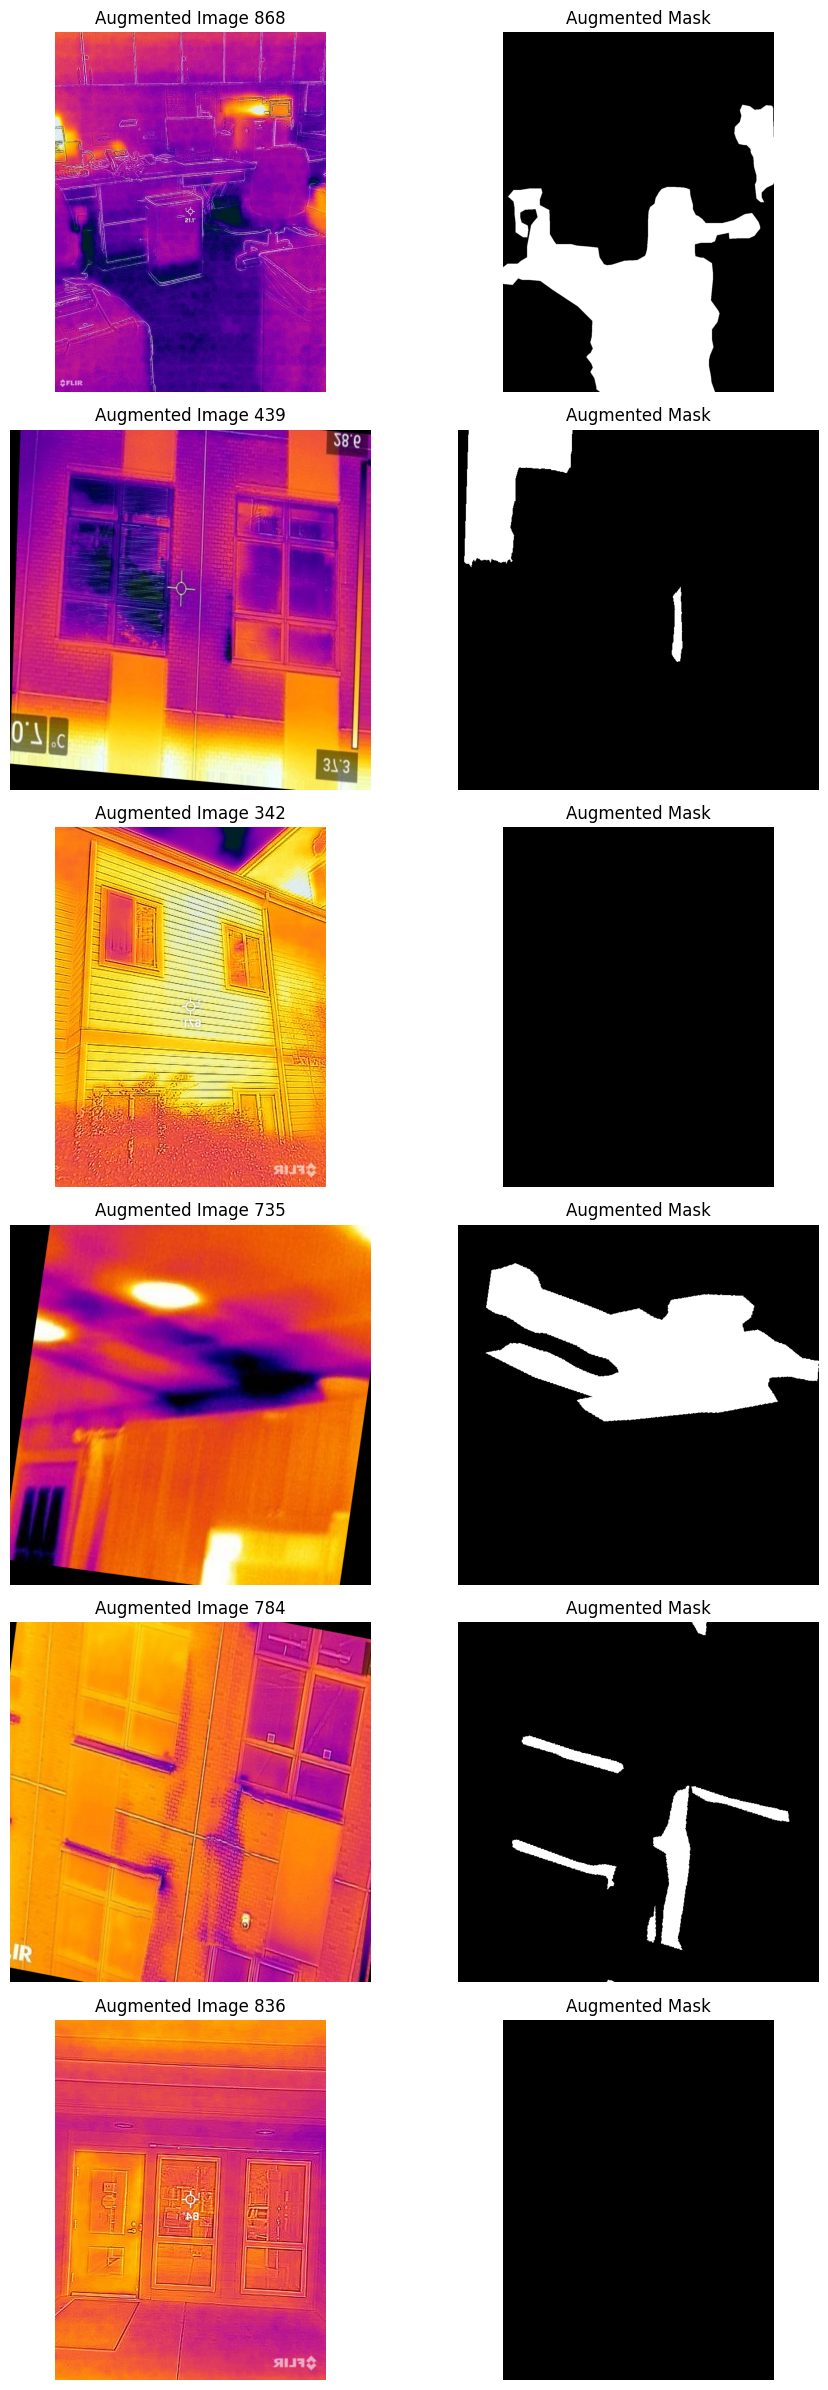

In [34]:
# CHECK OFFLINE AUGMENTATION

sample_indices = np.random.choice(
    len(augmented_df),
    size=min(6, len(augmented_df)),
    replace=False
)

fig, axes = plt.subplots(
    len(sample_indices),
    2,
    figsize=(10, 4 * len(sample_indices))
)

if len(sample_indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, sample_idx in enumerate(sample_indices):

    image_path = augmented_df.iloc[sample_idx]["image"]
    mask_path = augmented_df.iloc[sample_idx]["mask"]

    image = np.array(
        Image.open(image_path).convert("RGB")
    )

    mask = np.array(
        Image.open(mask_path).convert("L")
    )

    axes[row_idx, 0].imshow(image)
    axes[row_idx, 0].set_title(
        f"Augmented Image {sample_idx}"
    )
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(mask, cmap="gray")
    axes[row_idx, 1].set_title(
        "Augmented Mask"
    )
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.show()

In [35]:
# use the dynamic augmentation

offline_train_dataset = HumidityDataset(
    offline_train_df,
    transform=train_transform
)

offline_train_loader = DataLoader(
    offline_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

print(
    "Offline training samples:",
    len(offline_train_dataset)
)

print(
    "Batches per epoch:",
    len(offline_train_loader)
)

Offline training samples: 1814
Batches per epoch: 227


In [37]:
FOCAL_DICE_CHECKPOINT = Path(
    "/kaggle/working/deeplabv3plus_resnet50_focaldice.pth"
)

deeplab_r50_offline = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

checkpoint = torch.load(
    FOCAL_DICE_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

deeplab_r50_offline.load_state_dict(
    checkpoint["model_state_dict"]
)

deeplab_r50_offline.to(DEVICE)

print("=" * 70)
print("LOADED FOCAL+DICE R50 CHECKPOINT")
print("=" * 70)

print("Checkpoint:", FOCAL_DICE_CHECKPOINT)
print("Best epoch:", checkpoint["epoch"])
print("Best validation Dice:", checkpoint["best_val_dice"])

LOADED FOCAL+DICE R50 CHECKPOINT
Checkpoint: /kaggle/working/deeplabv3plus_resnet50_focaldice.pth
Best epoch: 16
Best validation Dice: 0.842240830057675


In [39]:
import time

OFFLINE_LR = 3e-5
NUM_EPOCHS = 30
PATIENCE = 8

optimizer = torch.optim.AdamW(
    deeplab_r50_offline.parameters(),
    lr=OFFLINE_LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

best_val_dice = -1.0
best_epoch = 0
epochs_without_improvement = 0

OFFLINE_BEST_CHECKPOINT = (
    "/kaggle/working/"
    "deeplabv3plus_resnet50_offline_focaldice_best.pth"
)

history_offline = []

print("=" * 70)
print("R50 OFFLINE AUGMENTATION EXPERIMENT")
print("=" * 70)
print(f"Training samples : {len(offline_train_dataset)}")
print(f"Validation       : {len(valid_dataset)}")
print(f"Loss             : Focal + Dice")
print(f"Learning rate    : {OFFLINE_LR}")
print(f"Batch size       : {BATCH_SIZE}")
print("=" * 70)

for epoch in range(1, NUM_EPOCHS + 1):

    start_time = time.time()

    # ======================================================
    # TRAIN
    # ======================================================

    deeplab_r50_offline.train()

    running_loss = 0.0
    n_samples = 0

    for images, masks in offline_train_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE.type == "cuda")
        ):

            logits = deeplab_r50_offline(images)

            loss = criterion_focal_dice(
                logits,
                masks
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            deeplab_r50_offline.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        n_samples += batch_size

    train_loss = (
        running_loss / n_samples
    )

    # ======================================================
    # VALIDATION
    # ======================================================

    val_results = validate_one_epoch(
        deeplab_r50_offline,
        valid_loader,
        criterion_focal_dice,
        DEVICE
    )

    val_dice = val_results["dice"]

    current_lr = optimizer.param_groups[0]["lr"]

    scheduler.step(val_dice)

    elapsed = time.time() - start_time

    history_offline.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_results["loss"],
        "val_dice": val_results["dice"],
        "val_iou": val_results["iou"],
        "val_precision": val_results["precision"],
        "val_recall": val_results["recall"],
        "lr": current_lr
    })

    # ======================================================
    # BEST CHECKPOINT
    # ======================================================

    if val_dice > best_val_dice:

        best_val_dice = val_dice
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    deeplab_r50_offline.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "best_val_dice":
                    best_val_dice,
                "val_results":
                    val_results,
                "lr":
                    current_lr
            },
            OFFLINE_BEST_CHECKPOINT
        )

        marker = " ★ BEST"

    else:

        epochs_without_improvement += 1
        marker = ""

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_results['loss']:.4f} | "
        f"Dice: {val_results['dice']:.4f} | "
        f"IoU: {val_results['iou']:.4f} | "
        f"Prec: {val_results['precision']:.4f} | "
        f"Recall: {val_results['recall']:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"{elapsed:.1f}s"
        f"{marker}"
    )

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}."
        )

        break


print("\n" + "=" * 70)
print("OFFLINE AUGMENTATION EXPERIMENT COMPLETE")
print("=" * 70)

print("Best epoch:", best_epoch)
print("Best validation Dice:", best_val_dice)
print("Checkpoint:", OFFLINE_BEST_CHECKPOINT)

R50 OFFLINE AUGMENTATION EXPERIMENT
Training samples : 1814
Validation       : 194
Loss             : Focal + Dice
Learning rate    : 3e-05
Batch size       : 8
Epoch 01/30 | Train Loss: 0.0702 | Val Loss: 0.1376 | Dice: 0.8321 | IoU: 0.7460 | Prec: 0.8776 | Recall: 0.8459 | LR: 3.00e-05 | 54.8s ★ BEST
Epoch 02/30 | Train Loss: 0.0688 | Val Loss: 0.1335 | Dice: 0.8314 | IoU: 0.7445 | Prec: 0.8513 | Recall: 0.8694 | LR: 3.00e-05 | 50.0s
Epoch 03/30 | Train Loss: 0.0671 | Val Loss: 0.1306 | Dice: 0.8353 | IoU: 0.7495 | Prec: 0.8521 | Recall: 0.8727 | LR: 3.00e-05 | 48.6s ★ BEST
Epoch 04/30 | Train Loss: 0.0667 | Val Loss: 0.1357 | Dice: 0.8359 | IoU: 0.7509 | Prec: 0.8587 | Recall: 0.8694 | LR: 3.00e-05 | 49.7s ★ BEST
Epoch 05/30 | Train Loss: 0.0639 | Val Loss: 0.1413 | Dice: 0.8271 | IoU: 0.7402 | Prec: 0.8553 | Recall: 0.8611 | LR: 3.00e-05 | 49.0s
Epoch 06/30 | Train Loss: 0.0655 | Val Loss: 0.1371 | Dice: 0.8294 | IoU: 0.7430 | Prec: 0.8461 | Recall: 0.8725 | LR: 3.00e-05 | 48.9s
Ep

#### Reject offline augmentation

# Experiment 4: Higher-resolution

In [40]:
# HIGH-RESOLUTION EXPERIMENT

HR_HEIGHT = 512
HR_WIDTH = 768

train_transform_hr = A.Compose([

    A.Resize(
        HR_HEIGHT,
        HR_WIDTH
    ),

    A.HorizontalFlip(p=0.5),

    A.Affine(
        scale=(0.90, 1.10),
        translate_percent=(-0.05, 0.05),
        rotate=(-10, 10),
        shear=(-3, 3),
        border_mode=0,
        fill=0,
        fill_mask=0,
        p=0.5
    ),

    A.OneOf([
        A.GaussNoise(p=1.0),
        A.GaussianBlur(
            blur_limit=(3, 5),
            p=1.0
        ),
    ], p=0.15),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])


valid_transform_hr = A.Compose([

    A.Resize(
        HR_HEIGHT,
        HR_WIDTH
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])

print(f"High-resolution training: {HR_HEIGHT} × {HR_WIDTH}")

High-resolution training: 512 × 768


In [41]:
BATCH_SIZE_HR = 4

train_dataset_hr = HumidityDataset(
    train_df,
    transform=train_transform_hr
)

valid_dataset_hr = HumidityDataset(
    valid_df,
    transform=valid_transform_hr
)

test_dataset_hr = HumidityDataset(
    test_df,
    transform=valid_transform_hr
)

train_loader_hr = DataLoader(
    train_dataset_hr,
    batch_size=BATCH_SIZE_HR,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

valid_loader_hr = DataLoader(
    valid_dataset_hr,
    batch_size=BATCH_SIZE_HR,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader_hr = DataLoader(
    test_dataset_hr,
    batch_size=BATCH_SIZE_HR,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

print("Training samples :", len(train_dataset_hr))
print("Validation samples:", len(valid_dataset_hr))
print("Test samples      :", len(test_dataset_hr))
print("Batches/epoch     :", len(train_loader_hr))

Training samples : 907
Validation samples: 194
Test samples      : 195
Batches/epoch     : 227


In [42]:
FOCAL_DICE_BASELINE = Path(
    "/kaggle/working/deeplabv3plus_resnet50_focaldice.pth"
)

deeplab_r50_hr = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

checkpoint_hr = torch.load(
    FOCAL_DICE_BASELINE,
    map_location=DEVICE,
    weights_only=False
)

deeplab_r50_hr.load_state_dict(
    checkpoint_hr["model_state_dict"]
)

deeplab_r50_hr.to(DEVICE)

print("=" * 70)
print("LOADED BASELINE FOR HIGH-RESOLUTION EXPERIMENT")
print("=" * 70)

print("Checkpoint:", FOCAL_DICE_BASELINE)
print("Best epoch:", checkpoint_hr["epoch"])
print(
    "Baseline validation Dice:",
    checkpoint_hr["best_val_dice"]
)

LOADED BASELINE FOR HIGH-RESOLUTION EXPERIMENT
Checkpoint: /kaggle/working/deeplabv3plus_resnet50_focaldice.pth
Best epoch: 16
Baseline validation Dice: 0.842240830057675


In [43]:
HR_LR = 3e-5
optimizer_hr = torch.optim.AdamW(
    deeplab_r50_hr.parameters(),
    lr=HR_LR,
    weight_decay=1e-4
)

scheduler_hr = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_hr,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

In [45]:
# Training
import time

NUM_EPOCHS_HR = 30
PATIENCE_HR = 8

best_val_dice_hr = -1.0
best_epoch_hr = 0
epochs_without_improvement_hr = 0

HR_CHECKPOINT = (
    "/kaggle/working/"
    "deeplabv3plus_resnet50_highres_focaldice_best.pth"
)

history_hr = []

print("=" * 70)
print("R50 HIGH-RESOLUTION EXPERIMENT")
print("=" * 70)

for epoch in range(1, NUM_EPOCHS_HR + 1):

    start_time = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    deeplab_r50_hr.train()

    running_loss = 0.0
    n_samples = 0

    for images, masks in train_loader_hr:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True
        )

        optimizer_hr.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE.type == "cuda")
        ):

            logits = deeplab_r50_hr(images)

            loss = criterion_focal_dice(
                logits,
                masks
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            deeplab_r50_hr.parameters(),
            max_norm=1.0
        )

        optimizer_hr.step()

        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        n_samples += batch_size

    train_loss = (
        running_loss / n_samples
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    val_results_hr = validate_one_epoch(
        deeplab_r50_hr,
        valid_loader_hr,
        criterion_focal_dice,
        DEVICE
    )

    val_dice_hr = val_results_hr["dice"]

    current_lr_hr = (
        optimizer_hr.param_groups[0]["lr"]
    )

    scheduler_hr.step(
        val_dice_hr
    )

    elapsed = time.time() - start_time

    history_hr.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_results_hr["loss"],
        "val_dice": val_results_hr["dice"],
        "val_iou": val_results_hr["iou"],
        "val_precision": val_results_hr["precision"],
        "val_recall": val_results_hr["recall"],
        "lr": current_lr_hr
    })

    # ========================================================
    # BEST MODEL
    # ========================================================

    if val_dice_hr > best_val_dice_hr:

        best_val_dice_hr = val_dice_hr
        best_epoch_hr = epoch
        epochs_without_improvement_hr = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    deeplab_r50_hr.state_dict(),
                "optimizer_state_dict":
                    optimizer_hr.state_dict(),
                "best_val_dice":
                    best_val_dice_hr,
                "val_results":
                    val_results_hr,
                "lr":
                    current_lr_hr,
                "resolution": (
                    HR_HEIGHT,
                    HR_WIDTH
                )
            },
            HR_CHECKPOINT
        )

        marker = " ★ BEST"

    else:

        epochs_without_improvement_hr += 1
        marker = ""

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS_HR} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_results_hr['loss']:.4f} | "
        f"Dice: {val_results_hr['dice']:.4f} | "
        f"IoU: {val_results_hr['iou']:.4f} | "
        f"Prec: {val_results_hr['precision']:.4f} | "
        f"Recall: {val_results_hr['recall']:.4f} | "
        f"LR: {current_lr_hr:.2e} | "
        f"{elapsed:.1f}s"
        f"{marker}"
    )

    if epochs_without_improvement_hr >= PATIENCE_HR:

        print(
            f"\nEarly stopping at epoch {epoch}."
        )

        break


print("\n" + "=" * 70)
print("HIGH-RESOLUTION EXPERIMENT COMPLETE")
print("=" * 70)

print("Best epoch:", best_epoch_hr)
print(
    "Best validation Dice:",
    best_val_dice_hr
)
print("Checkpoint:", HR_CHECKPOINT)

R50 HIGH-RESOLUTION EXPERIMENT
Epoch 01/30 | Train Loss: 0.0995 | Val Loss: 0.1433 | Dice: 0.8229 | IoU: 0.7344 | Prec: 0.8511 | Recall: 0.8601 | LR: 3.00e-05 | 57.8s ★ BEST
Epoch 02/30 | Train Loss: 0.0951 | Val Loss: 0.1381 | Dice: 0.8300 | IoU: 0.7434 | Prec: 0.8598 | Recall: 0.8581 | LR: 3.00e-05 | 52.5s ★ BEST
Epoch 03/30 | Train Loss: 0.0927 | Val Loss: 0.1382 | Dice: 0.8264 | IoU: 0.7391 | Prec: 0.8556 | Recall: 0.8586 | LR: 3.00e-05 | 50.9s
Epoch 04/30 | Train Loss: 0.0950 | Val Loss: 0.1253 | Dice: 0.8355 | IoU: 0.7489 | Prec: 0.8531 | Recall: 0.8739 | LR: 3.00e-05 | 51.7s ★ BEST
Epoch 05/30 | Train Loss: 0.0872 | Val Loss: 0.1345 | Dice: 0.8329 | IoU: 0.7451 | Prec: 0.8740 | Recall: 0.8474 | LR: 3.00e-05 | 51.6s
Epoch 06/30 | Train Loss: 0.0828 | Val Loss: 0.1299 | Dice: 0.8353 | IoU: 0.7484 | Prec: 0.8661 | Recall: 0.8599 | LR: 3.00e-05 | 51.2s
Epoch 07/30 | Train Loss: 0.0849 | Val Loss: 0.1492 | Dice: 0.8193 | IoU: 0.7314 | Prec: 0.8722 | Recall: 0.8365 | LR: 3.00e-05 | 51

### keep the 384×512 Resolution 

# Experiment 5: Separate encoder and decoder parameters

In [46]:
DISCRIMINATIVE_CHECKPOINT = Path(
    "/kaggle/working/deeplabv3plus_resnet50_focaldice.pth"
)

deeplab_r50_disc = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

checkpoint = torch.load(
    DISCRIMINATIVE_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

deeplab_r50_disc.load_state_dict(
    checkpoint["model_state_dict"]
)

deeplab_r50_disc.to(DEVICE)

print("=" * 70)
print("DISCRIMINATIVE LR EXPERIMENT")
print("=" * 70)
print("Starting checkpoint:", DISCRIMINATIVE_CHECKPOINT)
print("Original best epoch:", checkpoint["epoch"])
print("Original best validation Dice:",
      checkpoint["best_val_dice"])

DISCRIMINATIVE LR EXPERIMENT
Starting checkpoint: /kaggle/working/deeplabv3plus_resnet50_focaldice.pth
Original best epoch: 16
Original best validation Dice: 0.842240830057675


In [47]:
# PARAMETER GROUPS

encoder_params = list(
    deeplab_r50_disc.encoder.parameters()
)

decoder_params = list(
    deeplab_r50_disc.decoder.parameters()
)

segmentation_head_params = list(
    deeplab_r50_disc.segmentation_head.parameters()
)

# ============================================================
# DISCRIMINATIVE LEARNING RATE
# ============================================================

ENCODER_LR = 3e-6
DECODER_LR = 3e-5

optimizer_disc = torch.optim.AdamW(
    [
        {
            "params": encoder_params,
            "lr": ENCODER_LR
        },
        {
            "params": decoder_params,
            "lr": DECODER_LR
        },
        {
            "params": segmentation_head_params,
            "lr": DECODER_LR
        }
    ],
    weight_decay=1e-4
)

# ============================================================
# COSINE LR SCHEDULER
# ============================================================

NUM_EPOCHS_DISC = 30

scheduler_disc = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_disc,
    T_max=NUM_EPOCHS_DISC,
    eta_min=1e-7
)

In [48]:
# ============================================================
# DISCRIMINATIVE LR TRAINING
# ============================================================

def train_discriminative_lr(
    model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    num_epochs=30,
    patience=8,
    checkpoint_path=None
):

    best_dice = -float("inf")
    best_epoch = 0
    patience_counter = 0

    history = []

    for epoch in range(1, num_epochs + 1):

        model.train()

        running_loss = 0.0
        n_samples = 0

        epoch_start = time.time()

        for images, masks in train_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(device.type == "cuda")
            ):

                logits = model(images)

                loss = criterion(
                    logits,
                    masks
                )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            batch_size = images.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            n_samples += batch_size

        train_loss = (
            running_loss / n_samples
        )

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        val_results = validate_one_epoch(
            model,
            valid_loader,
            criterion,
            device
        )

        val_dice = val_results["dice"]

        # Current LRs BEFORE scheduler step
        encoder_lr = optimizer.param_groups[0]["lr"]
        decoder_lr = optimizer.param_groups[1]["lr"]

        scheduler.step()

        epoch_time = time.time() - epoch_start

        improved = val_dice > best_dice

        if improved:

            best_dice = val_dice
            best_epoch = epoch
            patience_counter = 0

            if checkpoint_path is not None:

                torch.save(
                    {
                        "epoch": epoch,
                        "model_state_dict":
                            model.state_dict(),
                        "optimizer_state_dict":
                            optimizer.state_dict(),
                        "scheduler_state_dict":
                            scheduler.state_dict(),
                        "best_val_dice":
                            best_dice,
                        "val_results":
                            val_results,
                        "encoder_lr":
                            encoder_lr,
                        "decoder_lr":
                            decoder_lr
                    },
                    checkpoint_path
                )

        else:

            patience_counter += 1

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_results["loss"],
            "dice": val_results["dice"],
            "iou": val_results["iou"],
            "precision": val_results["precision"],
            "recall": val_results["recall"],
            "encoder_lr": encoder_lr,
            "decoder_lr": decoder_lr
        })

        marker = " ★ BEST" if improved else ""

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_results['loss']:.4f} | "
            f"Dice: {val_results['dice']:.4f} | "
            f"IoU: {val_results['iou']:.4f} | "
            f"Prec: {val_results['precision']:.4f} | "
            f"Recall: {val_results['recall']:.4f} | "
            f"Enc LR: {encoder_lr:.2e} | "
            f"Dec LR: {decoder_lr:.2e} | "
            f"{epoch_time:.1f}s"
            f"{marker}"
        )

        if patience_counter >= patience:

            print(
                f"\nEarly stopping at epoch {epoch}."
            )

            break

    print("\n" + "=" * 70)
    print("DISCRIMINATIVE LR EXPERIMENT COMPLETE")
    print("=" * 70)

    print("Best epoch:", best_epoch)
    print("Best validation Dice:", best_dice)

    if checkpoint_path is not None:
        print("Checkpoint:", checkpoint_path)

    return pd.DataFrame(history)

In [49]:
# RUN DISCRIMINATIVE LR EXPERIMENT

DISCRIMINATIVE_CHECKPOINT_OUT = Path(
    "/kaggle/working/"
    "deeplabv3plus_resnet50_discriminative_lr_best.pth"
)

history_disc = train_discriminative_lr(
    model=deeplab_r50_disc,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion_focal_dice,
    optimizer=optimizer_disc,
    scheduler=scheduler_disc,
    device=DEVICE,
    num_epochs=30,
    patience=8,
    checkpoint_path=DISCRIMINATIVE_CHECKPOINT_OUT
)

Epoch 01/30 | Train Loss: 0.0668 | Val Loss: 0.1283 | Dice: 0.8378 | IoU: 0.7518 | Prec: 0.8503 | Recall: 0.8780 | Enc LR: 3.00e-06 | Dec LR: 3.00e-05 | 30.6s ★ BEST
Epoch 02/30 | Train Loss: 0.0690 | Val Loss: 0.1271 | Dice: 0.8407 | IoU: 0.7557 | Prec: 0.8668 | Recall: 0.8656 | Enc LR: 2.99e-06 | Dec LR: 2.99e-05 | 25.5s ★ BEST
Epoch 03/30 | Train Loss: 0.0684 | Val Loss: 0.1269 | Dice: 0.8392 | IoU: 0.7542 | Prec: 0.8557 | Recall: 0.8751 | Enc LR: 2.97e-06 | Dec LR: 2.97e-05 | 25.7s
Epoch 04/30 | Train Loss: 0.0641 | Val Loss: 0.1272 | Dice: 0.8399 | IoU: 0.7550 | Prec: 0.8602 | Recall: 0.8716 | Enc LR: 2.93e-06 | Dec LR: 2.93e-05 | 26.8s
Epoch 05/30 | Train Loss: 0.0647 | Val Loss: 0.1368 | Dice: 0.8352 | IoU: 0.7481 | Prec: 0.8685 | Recall: 0.8551 | Enc LR: 2.87e-06 | Dec LR: 2.87e-05 | 25.6s
Epoch 06/30 | Train Loss: 0.0650 | Val Loss: 0.1295 | Dice: 0.8374 | IoU: 0.7513 | Prec: 0.8555 | Recall: 0.8716 | Enc LR: 2.81e-06 | Dec LR: 2.80e-05 | 25.8s
Epoch 07/30 | Train Loss: 0.0628

# Experiment 6: boundary-aware extension

In [56]:
class BoundaryAwareFocalDiceLoss(nn.Module):
    def __init__(
        self,
        focal_weight=0.5,
        dice_weight=0.4,
        boundary_weight=0.1,
        focal_alpha=0.25,
        focal_gamma=2.0,
        smooth=1.0
    ):
        super().__init__()

        self.focal_weight = focal_weight
        self.dice_weight = dice_weight
        self.boundary_weight = boundary_weight

        self.focal_alpha = focal_alpha
        self.focal_gamma = focal_gamma
        self.smooth = smooth

    def dice_loss(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.flatten(1)
        targets = targets.flatten(1)

        intersection = (probs * targets).sum(dim=1)

        dice = (
            2.0 * intersection + self.smooth
        ) / (
            probs.sum(dim=1)
            + targets.sum(dim=1)
            + self.smooth
        )

        return 1.0 - dice.mean()

    def focal_loss(self, logits, targets):

        # AMP-safe BCE calculation
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )

        probs = torch.sigmoid(logits)

        p_t = (
            probs * targets
            + (1.0 - probs) * (1.0 - targets)
        )

        alpha_t = (
            self.focal_alpha * targets
            + (1.0 - self.focal_alpha) * (1.0 - targets)
        )

        focal = (
            alpha_t
            * (1.0 - p_t).pow(self.focal_gamma)
            * bce
        )

        return focal.mean()

    def boundary_loss(self, logits, targets):

        probs = torch.sigmoid(logits)

        # Sobel-like finite differences
        pred_dx = torch.abs(
            probs[:, :, :, 1:] -
            probs[:, :, :, :-1]
        )

        pred_dy = torch.abs(
            probs[:, :, 1:, :] -
            probs[:, :, :-1, :]
        )

        target_dx = torch.abs(
            targets[:, :, :, 1:] -
            targets[:, :, :, :-1]
        )

        target_dy = torch.abs(
            targets[:, :, 1:, :] -
            targets[:, :, :-1, :]
        )

        loss_x = F.l1_loss(
            pred_dx,
            target_dx
        )

        loss_y = F.l1_loss(
            pred_dy,
            target_dy
        )

        return 0.5 * (loss_x + loss_y)

    def forward(self, logits, targets):

        focal = self.focal_loss(
            logits,
            targets
        )

        dice = self.dice_loss(
            logits,
            targets
        )

        boundary = self.boundary_loss(
            logits,
            targets
        )

        total = (
            self.focal_weight * focal
            + self.dice_weight * dice
            + self.boundary_weight * boundary
        )

        return total

criterion_boundary = BoundaryAwareFocalDiceLoss(
    focal_weight=0.5,
    dice_weight=0.4,
    boundary_weight=0.1
)

In [52]:
# ============================================================
# LOAD CURRENT CHAMPION
# ============================================================

BOUNDARY_START_CHECKPOINT = Path(
    "/kaggle/working/"
    "deeplabv3plus_resnet50_focaldice.pth"
)

deeplab_r50_boundary = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

checkpoint = torch.load(
    BOUNDARY_START_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

deeplab_r50_boundary.load_state_dict(
    checkpoint["model_state_dict"]
)

deeplab_r50_boundary.to(DEVICE)

print("=" * 70)
print("BOUNDARY EXPERIMENT — STARTING MODEL")
print("=" * 70)

print("Checkpoint:", BOUNDARY_START_CHECKPOINT)
print("Previous best epoch:", checkpoint["epoch"])
print(
    "Previous best Val Dice:",
    checkpoint["best_val_dice"]
)

BOUNDARY EXPERIMENT — STARTING MODEL
Checkpoint: /kaggle/working/deeplabv3plus_resnet50_focaldice.pth
Previous best epoch: 16
Previous best Val Dice: 0.842240830057675


In [53]:
# ============================================================
# OPTIMIZER
# ============================================================

BOUNDARY_LR = 3e-5

optimizer_boundary = torch.optim.AdamW(
    deeplab_r50_boundary.parameters(),
    lr=BOUNDARY_LR,
    weight_decay=1e-4
)

scheduler_boundary = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_boundary,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

In [54]:
# BOUNDARY-AWARE TRAINING

def train_boundary_experiment(
    model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    num_epochs=30,
    patience=8,
    checkpoint_path=None
):

    best_dice = -float("inf")
    best_epoch = 0
    patience_counter = 0

    history = []

    for epoch in range(1, num_epochs + 1):

        model.train()

        running_loss = 0.0
        n_samples = 0

        epoch_start = time.time()

        for images, masks in train_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(device.type == "cuda")
            ):

                logits = model(images)

                loss = criterion(
                    logits,
                    masks
                )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            batch_size = images.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            n_samples += batch_size

        train_loss = (
            running_loss / n_samples
        )

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        val_results = validate_one_epoch(
            model,
            valid_loader,
            criterion,
            device
        )

        val_dice = val_results["dice"]

        scheduler.step(val_dice)

        current_lr = optimizer.param_groups[0]["lr"]

        epoch_time = (
            time.time() - epoch_start
        )

        improved = val_dice > best_dice

        if improved:

            best_dice = val_dice
            best_epoch = epoch
            patience_counter = 0

            if checkpoint_path is not None:

                torch.save(
                    {
                        "epoch": epoch,
                        "model_state_dict":
                            model.state_dict(),
                        "optimizer_state_dict":
                            optimizer.state_dict(),
                        "scheduler_state_dict":
                            scheduler.state_dict(),
                        "best_val_dice":
                            best_dice,
                        "val_results":
                            val_results,
                        "learning_rate":
                            current_lr
                    },
                    checkpoint_path
                )

        else:

            patience_counter += 1

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_results["loss"],
            "dice": val_results["dice"],
            "iou": val_results["iou"],
            "precision": val_results["precision"],
            "recall": val_results["recall"],
            "lr": current_lr
        })

        marker = " ★ BEST" if improved else ""

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_results['loss']:.4f} | "
            f"Dice: {val_results['dice']:.4f} | "
            f"IoU: {val_results['iou']:.4f} | "
            f"Prec: {val_results['precision']:.4f} | "
            f"Recall: {val_results['recall']:.4f} | "
            f"LR: {current_lr:.2e} | "
            f"{epoch_time:.1f}s"
            f"{marker}"
        )

        if patience_counter >= patience:

            print(
                f"\nEarly stopping at epoch {epoch}."
            )

            break

    print("\n" + "=" * 70)
    print("BOUNDARY-AWARE EXPERIMENT COMPLETE")
    print("=" * 70)

    print("Best epoch:", best_epoch)
    print("Best validation Dice:", best_dice)

    if checkpoint_path is not None:
        print("Checkpoint:", checkpoint_path)

    return pd.DataFrame(history)

In [57]:
# RUN BOUNDARY-AWARE EXPERIMENT

BOUNDARY_CHECKPOINT_OUT = Path(
    "/kaggle/working/"
    "deeplabv3plus_resnet50_focaldice_boundary_best.pth"
)

history_boundary = train_boundary_experiment(
    model=deeplab_r50_boundary,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion_boundary,
    optimizer=optimizer_boundary,
    scheduler=scheduler_boundary,
    device=DEVICE,
    num_epochs=30,
    patience=8,
    checkpoint_path=BOUNDARY_CHECKPOINT_OUT
)

Epoch 01/30 | Train Loss: 0.0580 | Val Loss: 0.1028 | Dice: 0.8347 | IoU: 0.7473 | Prec: 0.8794 | Recall: 0.8440 | LR: 3.00e-05 | 28.7s ★ BEST
Epoch 02/30 | Train Loss: 0.0560 | Val Loss: 0.1010 | Dice: 0.8370 | IoU: 0.7515 | Prec: 0.8818 | Recall: 0.8467 | LR: 3.00e-05 | 25.9s ★ BEST
Epoch 03/30 | Train Loss: 0.0590 | Val Loss: 0.0966 | Dice: 0.8419 | IoU: 0.7571 | Prec: 0.8770 | Recall: 0.8571 | LR: 3.00e-05 | 25.7s ★ BEST
Epoch 04/30 | Train Loss: 0.0553 | Val Loss: 0.1011 | Dice: 0.8341 | IoU: 0.7465 | Prec: 0.8836 | Recall: 0.8382 | LR: 3.00e-05 | 27.0s
Epoch 05/30 | Train Loss: 0.0553 | Val Loss: 0.1047 | Dice: 0.8322 | IoU: 0.7448 | Prec: 0.8690 | Recall: 0.8496 | LR: 3.00e-05 | 25.9s
Epoch 06/30 | Train Loss: 0.0540 | Val Loss: 0.1048 | Dice: 0.8294 | IoU: 0.7421 | Prec: 0.8821 | Recall: 0.8345 | LR: 3.00e-05 | 25.9s
Epoch 07/30 | Train Loss: 0.0540 | Val Loss: 0.1111 | Dice: 0.8187 | IoU: 0.7288 | Prec: 0.8956 | Recall: 0.8063 | LR: 1.50e-05 | 26.5s
Epoch 08/30 | Train Loss: 0

# Optimized Model Evaluation

In [3]:
# LOAD FINAL OPTIMIZED R50

FINAL_R50_CHECKPOINT = Path(
    "/kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet50_focaldice_lr3e5.pth"
)

final_r50 = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

checkpoint = torch.load(
    FINAL_R50_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

final_r50.load_state_dict(
    checkpoint["model_state_dict"]
)

final_r50.to(DEVICE)
final_r50.eval()

print("=" * 70)
print("FINAL OPTIMIZED R50 LOADED")
print("=" * 70)
print("Checkpoint:", FINAL_R50_CHECKPOINT)
print("Best epoch:", checkpoint["epoch"])
print("Best validation Dice:", checkpoint["best_val_dice"])

FINAL OPTIMIZED R50 LOADED
Checkpoint: /kaggle/input/datasets/ebyeager/results/deeplabv3plus_resnet50_focaldice_lr3e5.pth
Best epoch: 16
Best validation Dice: 0.842240830057675


In [9]:
# FINAL R50 — TEST SET EVALUATION
# Selected threshold from validation: 0.425

FINAL_THRESHOLD = 0.425

@torch.no_grad()
def evaluate_test_set(
    model,
    loader,
    criterion,
    device,
    threshold=0.425
):
    model.eval()

    running_loss = 0.0
    n_samples = 0

    metric_totals = {
        "dice": 0.0,
        "iou": 0.0,
        "precision": 0.0,
        "recall": 0.0
    }

    for images, masks in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):
            logits = model(images)

            loss = criterion(
                logits,
                masks
            )

        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities >= threshold
        ).float()

        predictions = predictions.view(
            predictions.size(0), -1
        )

        masks_flat = masks.view(
            masks.size(0), -1
        )

        tp = (
            predictions * masks_flat
        ).sum(dim=1)

        fp = (
            predictions * (1 - masks_flat)
        ).sum(dim=1)

        fn = (
            (1 - predictions) * masks_flat
        ).sum(dim=1)

        eps = 1e-7

        dice = (
            (2 * tp + eps) /
            (2 * tp + fp + fn + eps)
        )

        iou = (
            (tp + eps) /
            (tp + fp + fn + eps)
        )

        precision = (
            (tp + eps) /
            (tp + fp + eps)
        )

        recall = (
            (tp + eps) /
            (tp + fn + eps)
        )

        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        metric_totals["dice"] += (
            dice.mean().item() * batch_size
        )

        metric_totals["iou"] += (
            iou.mean().item() * batch_size
        )

        metric_totals["precision"] += (
            precision.mean().item() * batch_size
        )

        metric_totals["recall"] += (
            recall.mean().item() * batch_size
        )

        n_samples += batch_size

    return {
        "loss": running_loss / n_samples,
        "dice": metric_totals["dice"] / n_samples,
        "iou": metric_totals["iou"] / n_samples,
        "precision": metric_totals["precision"] / n_samples,
        "recall": metric_totals["recall"] / n_samples
    }


final_r50_test_results = evaluate_test_set(
    final_r50,
    test_loader,
    criterion_focal_dice,
    DEVICE,
    threshold=FINAL_THRESHOLD
)

print("=" * 70)
print("FINAL OPTIMIZED R50 — TEST RESULTS")
print("=" * 70)

print(f"Threshold   : {FINAL_THRESHOLD:.3f}")

for metric, value in final_r50_test_results.items():
    print(
        f"{metric.capitalize():12s}: {value:.4f}"
    )

FINAL OPTIMIZED R50 — TEST RESULTS
Threshold   : 0.425
Loss        : 0.1358
Dice        : 0.8285
Iou         : 0.7462
Precision   : 0.8498
Recall      : 0.8610


### The optimized model gets worse results.